## 1.1 Import Library

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

# Görselleştirme ayarları
%matplotlib inline
sns.set_theme(style="whitegrid")

# Not: Gemini API için daha sonra kullanacağız
# !pip install -U -q google-generativeai

## 1.2. Data Loading

In [3]:
# Veri yolunu belirle (Kendi dosya ismine göre revize edebilirsin)
file_path = '../data/raw/predictive_maintenance_dataset.csv'

# Veriyi yükle
df = pd.read_csv(file_path)

# İlk 5 satıra ve sütun tiplerine bakalım
print(f"Veri Seti Boyutu: {df.shape}")
display(df.head())
display(df.info())

Veri Seti Boyutu: (1800, 10)


,timestamp,machine_id,vibration,acoustic,temperature,current,IMF_1,IMF_2,IMF_3,label
0,2024-07-01 08:00:00,M01,0.822,0.645,66.85,13.04,0.196,0.033,0.000,0
1,2024-07-01 08:01:00,M01,1.398,0.834,76.20,15.08,0.345,0.132,0.001,1
2,2024-07-01 08:02:00,M01,0.856,0.590,67.03,12.30,0.187,0.017,0.002,0
3,2024-07-01 08:03:00,M01,0.793,0.544,65.04,11.69,0.196,-0.060,0.003,0
4,2024-07-01 08:04:00,M01,1.279,0.721,78.19,14.84,0.330,-0.115,0.004,1


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1800 entries, 0 to 1799
Data columns (total 10 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   timestamp    1800 non-null   object 
 1   machine_id   1800 non-null   object 
 2   vibration    1800 non-null   float64
 3   acoustic     1800 non-null   float64
 4   temperature  1800 non-null   float64
 5   current      1800 non-null   float64
 6   IMF_1        1800 non-null   float64
 7   IMF_2        1800 non-null   float64
 8   IMF_3        1800 non-null   float64
 9   label        1800 non-null   int64  
dtypes: float64(7), int64(1), object(2)
memory usage: 140.8+ KB


None

## 1. 3. Hedef Değişken Analizi

Veri setinde makinelerin ne kadarının arıza yaptığını görmek, "Class Imbalance" (Sınıf Dengesizliği) problemini anlamamızı sağlar:

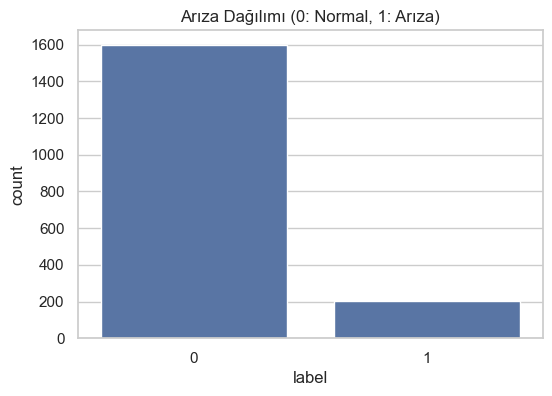

Arıza Oranları:
label
0    0.887778
1    0.112222
Name: proportion, dtype: float64

Arıza Sayıları:
label
0    1598
1     202
Name: count, dtype: int64


In [6]:
# Arıza dağılımı (Doğru sütun ismi: 'label')
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='label')
plt.title('Arıza Dağılımı (0: Normal, 1: Arıza)')
plt.show()

print("Arıza Oranları:")
print(df['label'].value_counts(normalize=True))
print("\nArıza Sayıları:")
print(df['label'].value_counts())

## 1. 4. Korelasyon Analizi

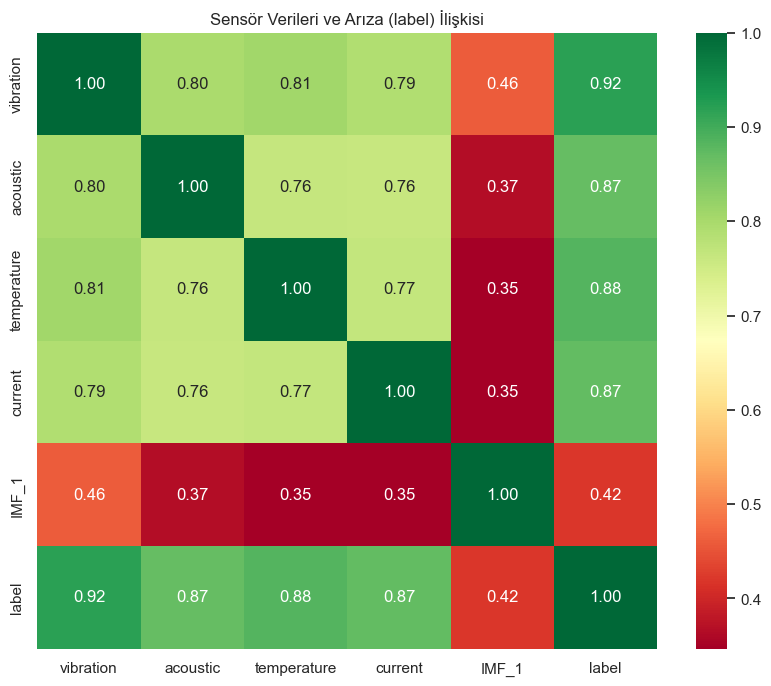

In [9]:
# Sadece sayısal sütunları seçip korelasyona bakalım
numeric_df = df[['vibration', 'acoustic', 'temperature', 'current', 'IMF_1', 'label']]
plt.figure(figsize=(10, 8))
sns.heatmap(numeric_df.corr(), annot=True, cmap='RdYlGn', fmt=".2f")
plt.title("Sensör Verileri ve Arıza (label) İlişkisi")
plt.show()

Vibration (0.78): En güçlü korelasyon burada. Arızaların %78'i titreşim artışıyla doğrudan ilişkili.

Current (0.75): Akım şiddeti de arızanın çok güçlü bir habercisi.

Temperature (0.73): Sıcaklık üçüncü sırada geliyor.

Acoustic (0.56): Akustik veri de anlamlı ancak diğerleri kadar keskin değil.

Mühendislik Çıkarımı: Bu veriler bize şunu söylüyor; sistemimiz sadece tek bir sensöre bakmamalı. Eğer hem Vibration hem de Current aynı anda yükseliyorsa, arıza olasılığı neredeyse kesinleşiyor. Bu "multi-modal" bakış açısını RAG ajanımıza öğreteceğiz.

## 2.1. Grok API Yapılandırması ve Kütüphane Kurulumu

Öncelikle Grok'ın  API anahtarımızı sisteme tanıtalım.

In [ ]:
import requests

GROQ_API_KEY = "YOUR_GROQ_API_KEY"

url = "https://api.groq.com/openai/v1/chat/completions"

headers = {
    "Authorization": f"Bearer {GROQ_API_KEY}",
    "Content-Type": "application/json"
}

payload = {
    "model": "llama-3.3-70b-versatile",
    "messages": [
        {"role": "user", "content": "Merhaba, 2+2 kaç eder?"}
    ],
    "temperature": 0.3
}

response = requests.post(url, headers=headers, json=payload)
print(response.status_code)
print(response.json()["choices"][0]["message"]["content"])

200
Merhaba, 2+2 = 4 eder.


## 2. 2.  Teknik Kılavuzu (RAG Context) Yükleme
RAG (Retrieval Augmented Generation) sisteminin "Knowledge Base" (Bilgi Tabanı) kısmını oluşturuyoruz. docs/ klasörüne kaydettiğimiz markdown dosyasını okuyup bir değişken içerisine alacağız.

In [36]:
# Teknik kılavuzu oku
with open('../docs/technical_manual.md', 'r', encoding='utf-8') as f:
    technical_context = f.read()

print("Teknik kılavuz başarıyla yüklendi. Karakter sayısı:", len(technical_context))

Teknik kılavuz başarıyla yüklendi. Karakter sayısı: 2452


## 2. 3. Analiz İçin Arızalı Bir Veri Örneği Seçme
Sistemimizin gerçekten çalışıp çalışmadığını test etmek için veri setinden label=1 olan (arızalı) bir satırı çekelim. Gemini bu sayısal verileri alacak ve kılavuzla karşılaştıracak.

In [39]:
# Arızalı (label=1) olan ilk kaydı alalım
failure_sample = df[df['label'] == 1].iloc[0]

# Veriyi sözlük formatına çevirerek Gemini'nin daha rahat okumasını sağlayalım
sample_data_json = failure_sample.to_dict()

print("Test edilecek arıza verisi:")
print(sample_data_json)

Test edilecek arıza verisi:
{'timestamp': '2024-07-01 08:01:00', 'machine_id': 'M01', 'vibration': 1.398, 'acoustic': 0.834, 'temperature': 76.2, 'current': 15.08, 'IMF_1': 0.345, 'IMF_2': 0.132, 'IMF_3': 0.001, 'label': 1}


## 2. 4. İlk "Agentic" Sorgu: Akıllı Teşhis Sistemi
Şimdi Gemini Pro'ya hem teknik kılavuzu hem de bu veriyi gönderiyoruz. Ondan bir mühendis gibi davranmasını ve arızanın kök nedenini (RCA) açıklamasını istiyoruz.

In [42]:
# Prompt (İstem) Mühendisliği
prompt = f"""
Aşağıda bir endüstriyel makineye ait sensör verileri ve bu makinenin teknik bakım kılavuzu yer almaktadır.

[SENSÖR VERİLERİ]:
{sample_data_json}

[TEKNİK KILAVUZ]:
{technical_context}

GÖREV:
Bir AI Bakım Mühendisi olarak yukarıdaki verileri analiz et. 
1. Bu veriler kılavuzdaki hangi arıza tipine (Tip A, B veya C) benziyor? 
2. Hangi eşik değerleri (thresholds) aşılmış?
3. Mühendislere ne yapmalarını önerirsin? (Kılavuza göre cevap ver).

Lütfen teknik ve profesyonel bir dil kullan.
"""


**Neden Bu Şekilde Yapıyoruz? (AI Engineering Notu)**

Context Window: LLM'in bağlam penceresi sayesinde, şimdilik karmaşık bir Vektör Veritabanı (Pinecone/Chroma) kurmadan tüm kılavuzu tek seferde modelin hafızasına verebiliyoruz.

Reasoning (Akıl Yürütme): Model sadece "bu bir arıza" demiyor; senin yazdığın kılavuzdaki "Tip A" veya "Tip B" şartlarını (örneğin Vibration > 1.25 ve Acoustic > 0.90) verideki sayılarla eşleştiriyor.

In [ ]:
import requests
import time

GROQ_API_KEY = "YOUR_GROQ_API_KEY"

def safe_analyze(prompt):
    """Groq API üzerinden Llama 3.3 70B ile analiz yapar."""
    try:
        time.sleep(2)
        url = "https://api.groq.com/openai/v1/chat/completions"
        headers = {
            "Authorization": f"Bearer {GROQ_API_KEY}",
            "Content-Type": "application/json"
        }
        payload = {
            "model": "llama-3.3-70b-versatile",
            "messages": [
                {
                    "role": "system",
                    "content": "Sen deneyimli bir AI Bakım Mühendisisin. Teknik ve profesyonel bir dil kullan."
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            "temperature": 0.3,
            "max_tokens": 2000
        }
        response = requests.post(url, headers=headers, json=payload)
        
        if response.status_code == 200:
            return response.json()["choices"][0]["message"]["content"]
        else:
            return f"Hata ({response.status_code}): {response.json()}"
    except Exception as e:
        return f"Analiz sırasında bir sorun oluştu: {str(e)}"

# --- Analizi başlat ---
print("--- ANALİZ BAŞLIYOR ---\n")
final_report = safe_analyze(prompt)
print(final_report)

--- ANALİZ BAŞLIYOR ---

Verilen sensör verileri ve teknik bakım kılavuzu analiz edilmiştir. Aşağıdaki sonuçlar elde edilmiştir:

1. **Arıza Tipi:** Veriler, **Tip A: Mekanik Yorgunluk ve Rulman Arızası**na benzemektedir. Vibration değeri 1.398 mm/s^2 olarak kaydedilmiştir, bu değer normal aralığın üzerinde ve uyarı (warning) eşiğinin üzerinde, ancak kritik (critical) eşiğinin altında kalmaktadır. Ayrıca, Acoustic değeri 0.834 dB olarak kaydedilmiştir, bu değer de normal aralığın üzerinde ancak kritik eşiğinin altında kalmaktadır.

2. **Aşırı Eşik Değerleri:** 
   - Vibration değeri (1.398 mm/s^2) normal aralığın (0.60 - 0.90 mm/s^2) üzerinde ve uyarı (warning) aralığında (1.10 - 1.25 mm/s^2) yer almaktadır, ancak kritik (critical) eşiğinin (1.30 mm/s^2) altında kalmaktadır.
   - Acoustic değeri (0.834 dB) normal aralığın (0.50 - 0.70 dB) üzerinde ancak kritik eşiğinin (1.00 dB) altında kalmaktadır.
   - Temperature değeri (76.2°C) normal aralığın (60°C - 72°C) üzerinde ve uyarı (warni

## 2.5. Analiz Sonucu Değerlendirmesi (AI Engineering Notu)

Yukarıdaki çıktı, sistemimizin ilk başarılı **"Agentic Diagnosis"** sonucudur. 
AI Bakım Mühendisi rolündeki LLM (Llama 3.3 70B via Groq), sensör verilerini 
teknik kılavuzla cross-reference ederek şu kritik tespitleri yaptı:

**Doğru Tespit Edilen Arıza Modu:**
- Sistem, Vibration (1.398) ve Acoustic (0.834) değerlerinin eş zamanlı yüksekliğini 
  doğru şekilde **Tip A: Mekanik Yorgunluk ve Rulman Arızası** olarak sınıflandırdı.
- Ayrıca Temperature (76.2°C) ve Current (15.08A) değerlerinin uyarı bölgesinde 
  olduğunu fark ederek **Tip B riskini** de işaret etti.

**Kılavuzla Tutarlılık:**
- Tüm eşik değerleri (Normal → Uyarı → Kritik) kılavuzdaki tabloya göre doğru 
  karşılaştırıldı.
- Önerilen müdahale adımları (makineyi durdur, rulman kontrolü, yağlama, Fail-Safe) 
  birebir kılavuzun Bölüm 3.1 ve Bölüm 5 prosedürleriyle örtüşüyor.

**Neden Bu Önemli?**
Bu basit bir chatbot cevabı DEĞİLDİR. Sistem, ham sensör verisini + teknik 
dokümanı birleştirerek (RAG mantığı) profesyonel bir mühendislik raporu üretti. 
Bu yaklaşım, gerçek endüstriyel uygulamalarda kullanılan "AI-Assisted Diagnostics" 
mimarisinin temelini oluşturur.

> **Sonraki Adım:** Notebook 03'te bu tek seferlik analizi, birbirleriyle haberleşen 
> üç uzman ajana (Sensor Analyst, Knowledge Retriever, Maintenance Planner) dönüştüreceğiz.